# Setup

## Libraries Loading

In [1]:
# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

# Models
from sklearn.ensemble import RandomForestClassifier
# make_scorer source: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.make_scorer.html
from sklearn.metrics import confusion_matrix, make_scorer, roc_auc_score
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.feature_selection import RFE
# clone source: https://scikit-learn.org/stable/modules/generated/sklearn.base.clone.html
from sklearn.base import clone

# Statistics
from scipy import stats

# Oversampling
# imblearn source: https://imbalanced-learn.org/stable/over_sampling.html
from imblearn.over_sampling import SMOTENC, SMOTE, ADASYN, BorderlineSMOTE, SVMSMOTE

# Utilitary
import src.utils.utils as ut
import src.utils.model_prep_eval as mod_prep

## Data Loading

### Wines Data

In [2]:
# Loads data from source and sets wine_id
wine_df = pd.read_csv(ut.get_project_file_path("src", "data", "transformed", "wines_clean.csv"))
wine_df = wine_df.reset_index(drop=False,)
wine_df = wine_df.rename(columns={"index": "wine_id"})

### Users Data

In [ ]:
# Loads and concatenates user data
users_data1 = pd.read_pickle(ut.get_project_file_path("src", "data", "synthetic", "simulation_07_0.008_0.65_n400_repchs.pkl"))
users_data2 = pd.read_pickle(ut.get_project_file_path("src", "data", "synthetic", "simulation_08_0.008_0.65_n1000_repchs.pkl"))
users_data_complete = pd.concat([users_data1, users_data2], axis=0)
users_data = users_data_complete.dropna()
users_data.shape

(6647, 8)

## Data Prep

### Joining Data

In [9]:
# Agrega la información de los usuarios al df de vinos
joined_data = pd.merge(wine_df, users_data, how="inner", on="wine_id")
joined_data.shape

(6647, 126)

### ETL

In [ ]:
# Agrega si el vino tenia match con el main pairing del user
recommend_df = joined_data.copy()
recommend_df["user_main_pairing"] = recommend_df["user_input"].apply(lambda x: x["main_pairing"])
recommend_df["has_user_main_pairing"] = recommend_df.apply(lambda row: 1 if row[row["user_main_pairing"]]==1 else 0, axis=1)

# Agrega los límites inferiores y superiores de sabor según la decisión del usuario
taste_list = ["body", "tannins", "sweetness", "acidity"]
for taste in taste_list:
    recommend_df["user_" + taste + "_min"] = recommend_df["user_input"].apply(lambda x: x["tastes"][taste][0])
    recommend_df["user_" + taste + "_max"] = recommend_df["user_input"].apply(lambda x: x["tastes"][taste][1])

# Agrega la distancia fuzzy sin escalar entre el sabor de vino y las preferencias del usuario
recommend_df["user_taste_distance_raw"] = recommend_df["metrics_global"].apply(lambda x: x["taste_distance_raw_gbl"])

(6647, 137)

### DataFrames For Models Creation

- `model_df`: dataframe base, quitando columnas derivadas de la creación sintética de datos y otras no útiles.

- `model_df_nooh`: dataframe sin columnas one-hot.

- `model_df_nocat`: dataframe sin columnas categóricas.

In [ ]:
# Carga de uvas, regions y pairings
grapes = pd.read_csv(ut.get_project_file_path("src", "data", "processed", "aux", "grapes.csv"))
grapes_list = list(grapes["grapes"])
region = pd.read_csv(ut.get_project_file_path("src", "data", "processed", "aux", "region.csv"))
region_list = list(region["region"])
pairings = pd.read_csv(ut.get_project_file_path("src", "data", "processed", "aux", "pairings.csv"))
pairings_list = list(pairings["pairings"])

# Quita columnas no útiles para la predicción
model_df = recommend_df.drop(columns=[
    "event_timestamp", "wine_id", "wine_link", "name", "winery", "style", "image",               # Original df columns
    "user_id", "user_input", "metrics_local", "metrics_global", "prob_like", "user_main_pairing" # User data columns
]).copy()      

# Quita columnas one hot (uvas y regions)
model_df_nooh = model_df.drop(columns=(grapes_list + region_list)).copy() # One-hot columns

# Quita columnas categóricas (maridajes)
model_df_nocat = model_df_nooh.drop(columns=pairings_list) # Categorical column

# Models

## Evaluación Económica

In [15]:
# Obtención de parámetros para evaluación económica (valoración de Confusion Matrix)
simulation_params = pd.read_pickle(ut.get_project_file_path("src", "data", "synthetic", "simulation_08_0.008_0.65_n1000_repchs_params.pkl"))
avg_tkt = model_df_nooh["price"].mean()
churn_like = simulation_params["liked_churn_rate"]
churn_dislike = simulation_params["disliked_churn_rate"]
print("Ticket Promedio:", avg_tkt, "\nChurn Like:", churn_like, "\nChurn Dislike:", churn_dislike)

Ticket Promedio: 20.293867910335493 
Churn Like: 0.008 
Churn Dislike: 0.65


### ✅ True Positive (TP)

Se recomienda un vino y al usuario le gusta.

El usuario tiene mayor probabilidad de quedarse (menor churn), por lo tanto se captura el valor esperado del ticket de recompra.

Fórmula:

$$\text{Valor}_{TP} = \text{AvgTkt} \times (1 - \text{Churn}_{like})$$

### ✅ True Negative (TN)

Se descarta un vino que al usuario no le gustaría, y se recomienda otro que podría gustarle.

Este caso depende de la precisión del modelo (Precision) para acertar la segunda recomendación. Se gana la diferencia entre:

- El valor esperado si se acertara la segunda recomendación.

- El valor perdido si se hubiera ofrecido el vino "malo" original.

Fórmula:
$$ \text{Valor}_{TN} = \text{AvgTkt} \times \left( \left( \left[ (1 - \text{Churn}_{like}) \times \text{Precision} \right] - \left[ \text{Churn}_{dislike} \times (1 - \text{Precision}) \right] \right) - (1 - \text{Churn}_{dislike}) \right)$$

### ❌ False Positive (FP)

Se recomienda un vino que no le gusta al usuario.

Esto aumenta fuertemente la probabilidad de churn, y se pierde el valor del ticket.

Fórmula:

$$\text{Valor}_{FP} = - \text{AvgTkt} \times \text{Churn}_{dislike}$$

### ❌ False Negative (FN)

Se descarta un vino que sí le habría gustado al usuario, y se le recomienda otro con menor probabilidad de acierto.

Se pierde el valor que se habría capturado si se recomendaba el vino correcto, ajustado por la incertidumbre de la nueva recomendación.

Fórmula:

$$\text{Valor}_{FN} = \text{AvgTkt} \times \left( \left( \left[ (1 - \text{Churn}_{like}) \times \text{Precision} \right] - \left[ \text{Churn}_{dislike} \times (1 - \text{Precision}) \right] \right) - (1 - \text{Churn}_{like}) \right)$$

### ⚠️ Notas:

- Precisión representa la probabilidad de que la segunda recomendación, luego de identificar una opción no recomendable, sea acertada.

## Evaluación de Oversampling

### Modelo Base

In [16]:
# Instanciación de modelo RandomForest base
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    class_weight="balanced"
)

### Evaluación de Algoritmos de Oversampling

# SMOTENC


----------------------------------------------------

Train Metrics:

              precision    recall  f1-score   support

         0.0       0.91      0.87      0.89      4227
         1.0       0.88      0.92      0.89      4227

    accuracy                           0.89      8454
   macro avg       0.89      0.89      0.89      8454
weighted avg       0.89      0.89      0.89      8454



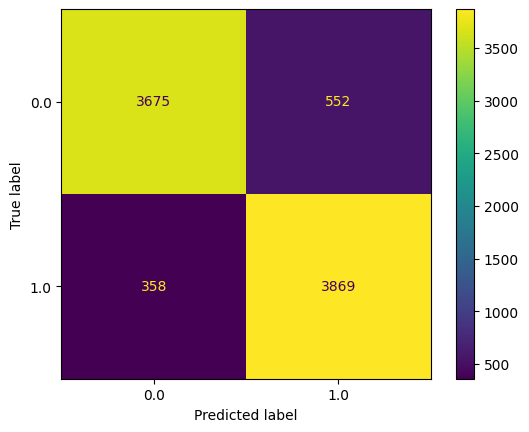

AUC Train: 0.9610834547966873

----------------------------------------------------

Test Metrics:

              precision    recall  f1-score   support

         0.0       0.82      0.79      0.80      1057
         1.0       0.79      0.83      0.81      1057

    accuracy                           0.81      2114
   macro avg       0.81      0.81      0.81      2114
weighted avg       0.81      0.81      0.81      2114



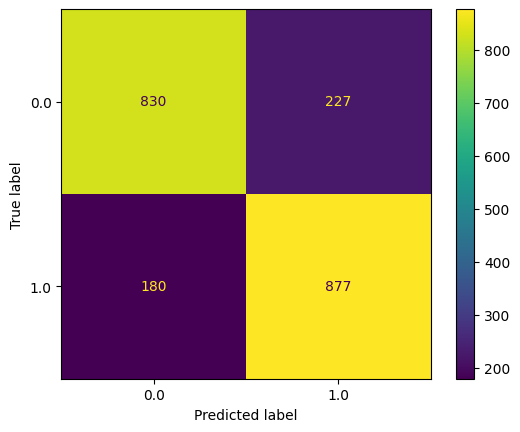

AUC Test: 0.8859269509303656
Gain from model: $18555


In [ ]:
# Entrenamiento y evaluación de modelo con oversampling categórico (SMOTENC)
idx_cat_features = [model_df_nooh.columns.get_loc(col) for col in pairings_list]

# Oversampling
X_smotenc, y_smotenc = mod_prep.oversample_df(
    df=model_df_nooh,
    sampling_object=SMOTENC,
    random_state=0,
    categorical_features=idx_cat_features
)

# Train test model
results_smotenc = mod_prep.train_test_model(
    X=X_smotenc,
    y=y_smotenc,
    model_object=rf_model,
    test_size=0.2,
    random_state=0,
    stratify=y_smotenc
)

# Visualización de resultados
display(Markdown("# SMOTENC"))
mod_prep.print_model_results(results_smotenc)
cm_pred = results_smotenc["cm_pred"]
eco_score = mod_prep.economic_score(
    conf_matrix=cm_pred,
    avg_tkt=avg_tkt,
    churn_like=churn_like,
    churn_dislike=churn_dislike
    )
print("Gain from model: $", round(eco_score), sep="")

# SMOTE


----------------------------------------------------

Train Metrics:

              precision    recall  f1-score   support

         0.0       0.91      0.88      0.90      4227
         1.0       0.89      0.92      0.90      4227

    accuracy                           0.90      8454
   macro avg       0.90      0.90      0.90      8454
weighted avg       0.90      0.90      0.90      8454



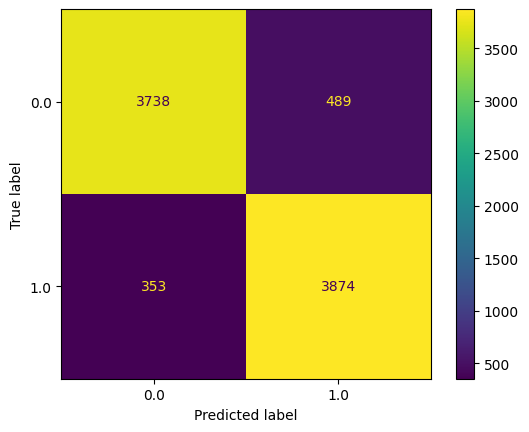

AUC Train: 0.9659675660803462

----------------------------------------------------

Test Metrics:

              precision    recall  f1-score   support

         0.0       0.83      0.80      0.81      1057
         1.0       0.80      0.83      0.82      1057

    accuracy                           0.82      2114
   macro avg       0.82      0.82      0.81      2114
weighted avg       0.82      0.82      0.81      2114



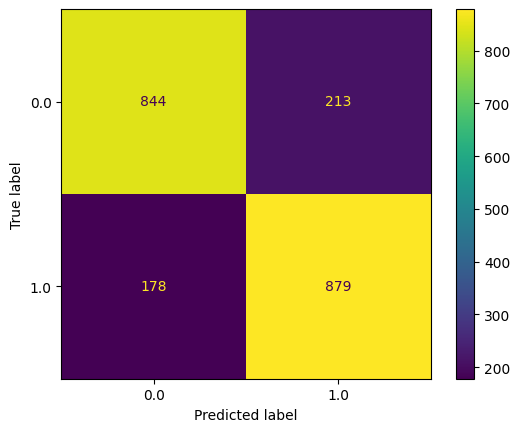

AUC Test: 0.8880374920899459
Gain from model: $19239


# ADASYN


----------------------------------------------------

Train Metrics:

              precision    recall  f1-score   support

         0.0       0.90      0.91      0.91      4201
         1.0       0.91      0.91      0.91      4227

    accuracy                           0.91      8428
   macro avg       0.91      0.91      0.91      8428
weighted avg       0.91      0.91      0.91      8428



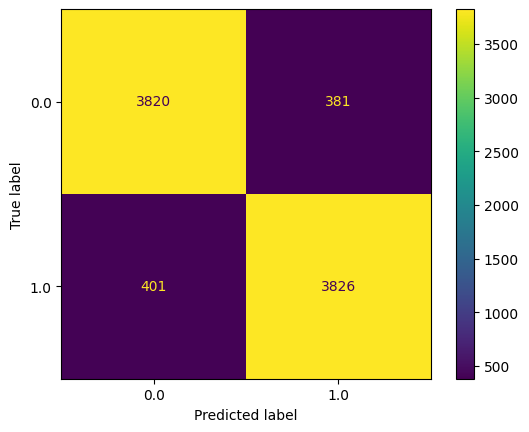

AUC Train: 0.969558150984926

----------------------------------------------------

Test Metrics:

              precision    recall  f1-score   support

         0.0       0.81      0.83      0.82      1050
         1.0       0.83      0.81      0.82      1057

    accuracy                           0.82      2107
   macro avg       0.82      0.82      0.82      2107
weighted avg       0.82      0.82      0.82      2107



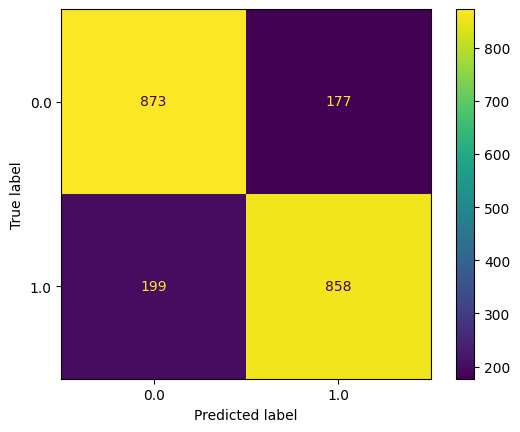

AUC Test: 0.8969730143713115
Gain from model: $20203


# BorderlineSMOTE


----------------------------------------------------

Train Metrics:

              precision    recall  f1-score   support

         0.0       0.90      0.90      0.90      4227
         1.0       0.90      0.90      0.90      4227

    accuracy                           0.90      8454
   macro avg       0.90      0.90      0.90      8454
weighted avg       0.90      0.90      0.90      8454



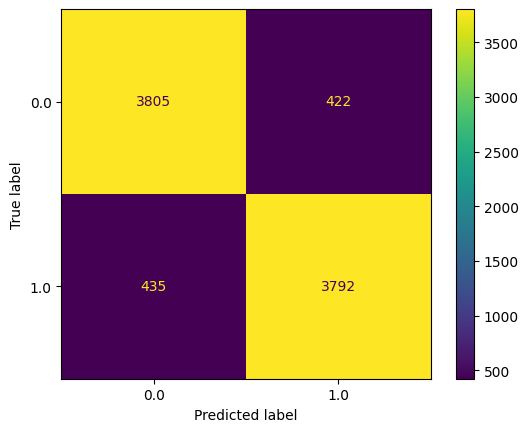

AUC Train: 0.9643278317891635

----------------------------------------------------

Test Metrics:

              precision    recall  f1-score   support

         0.0       0.83      0.84      0.83      1057
         1.0       0.84      0.82      0.83      1057

    accuracy                           0.83      2114
   macro avg       0.83      0.83      0.83      2114
weighted avg       0.83      0.83      0.83      2114



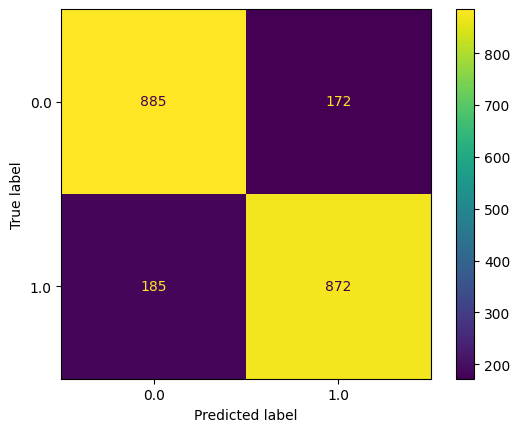

AUC Test: 0.8951442337384058
Gain from model: $20942


# SVMSMOTE


----------------------------------------------------

Train Metrics:

              precision    recall  f1-score   support

         0.0       0.94      0.82      0.88      4227
         1.0       0.84      0.95      0.89      4227

    accuracy                           0.88      8454
   macro avg       0.89      0.88      0.88      8454
weighted avg       0.89      0.88      0.88      8454



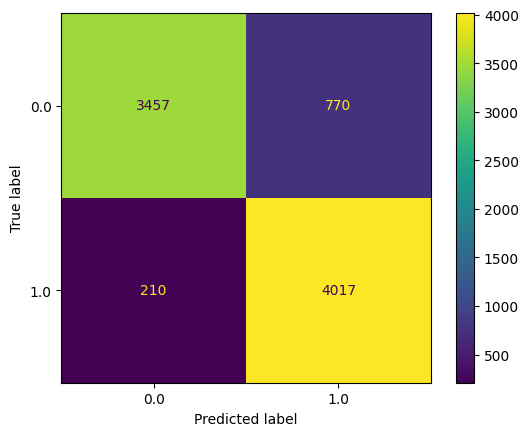

AUC Train: 0.9591789385090685

----------------------------------------------------

Test Metrics:

              precision    recall  f1-score   support

         0.0       0.86      0.74      0.80      1057
         1.0       0.77      0.88      0.82      1057

    accuracy                           0.81      2114
   macro avg       0.82      0.81      0.81      2114
weighted avg       0.82      0.81      0.81      2114



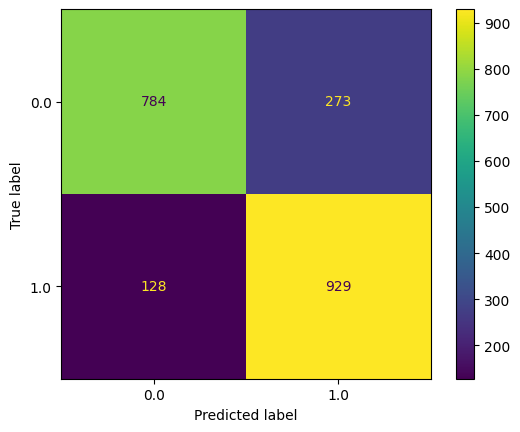

AUC Test: 0.8950967957903745
Gain from model: $18413


In [19]:
# Entrenamiento y evaluación de modelo con oversampling no categórico
sampling_objects = [SMOTE, ADASYN, BorderlineSMOTE, SVMSMOTE]

for obj in sampling_objects:
    # Oversampling
    X_resampled, y_resampled = mod_prep.oversample_df(
        df=model_df_nocat,
        sampling_object=obj,
        random_state=0,
    )
    # Train Test Model
    results_resampled = mod_prep.train_test_model(
        X=X_resampled,
        y=y_resampled,
        model_object=rf_model,
        test_size=0.2,
        random_state=0,
        stratify=y_resampled
    )
    # Visualización de resultados
    display(Markdown(f"# {obj.__name__}"))
    mod_prep.print_model_results(results_resampled)
    cm_pred = results_resampled["cm_pred"]
    eco_score = mod_prep.economic_score(
        conf_matrix=cm_pred,
        avg_tkt=avg_tkt,
        churn_like=churn_like,
        churn_dislike=churn_dislike
        )
    print("Gain from model: $", round(eco_score), sep="")